# COMP0189: Applied Artificial Intelligence
# Week 7 Dimensionality reduction

### 🎯 Objectives
1. To understand the differences in applying various dimensionality reduction techniques like Principal Component Analysis (PCA), Independent Component Analysis (ICA), Non-negative Matrix Factorization (NMF) to extract latent features from an image dataset
2. To apply cross decomposition methods like Canonical Correlation Analysis (CCA) and Partial Least Squares (PLS) to find the fundamental relations between two matrices (X and Y) that represent different views of the same data

### Acknowledgements
- https://scikit-learn.org/stable/
- https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html#sphx-glr-auto-examples-applications-plot-face-recognition-py
- https://oasis-brains.org
- https://cca-zoo.readthedocs.io/en/latest/preface.html

In [ ]:
%pip install scikit-learn==1.5.2 matplotlib==3.10.8 pandas==2.3.3 seaborn==0.13.2 cca-zoo==2.6.0 scipy==1.17.1 torch==2.10.0

  Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_curand_cu12-10.3.9.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cusolver_cu12

## 🧑‍💻 Part 1. Face recognition through eigenfaces and SVMs

This part of the lab will focus on different dimensionality reduction (or matrix decomposition) methods. We will use the [Labelled Faces in the Wild](https://scikit-learn.org/stable/datasets/real_world.html#labeled-faces-in-the-wild-dataset) (LFW) dataset distributed with `scikit-learn` to visualise the results of dimensionality reduction methods and assess their impact on model performance and training time.

The dataset provides the faces of several famous people labelled with their name. We will use it to train a model which predicts a person's name given a picture of their face.

### 📝 Task 1.1 Import Libraries and Load the Labeled Faces in the Wild (LFW) People Dataset (Classification)

First, we load in the LFW data.

In [ ]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

# Load data
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
n_features = X.shape[1]

# Split into a training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### 📝 Task 1.2 Visualise input data

To get an idea of what we're working with, we can visualise the first few faces in the dataset and their associated name. We will later reuse this function to draw the main components from dimensionality reduction.

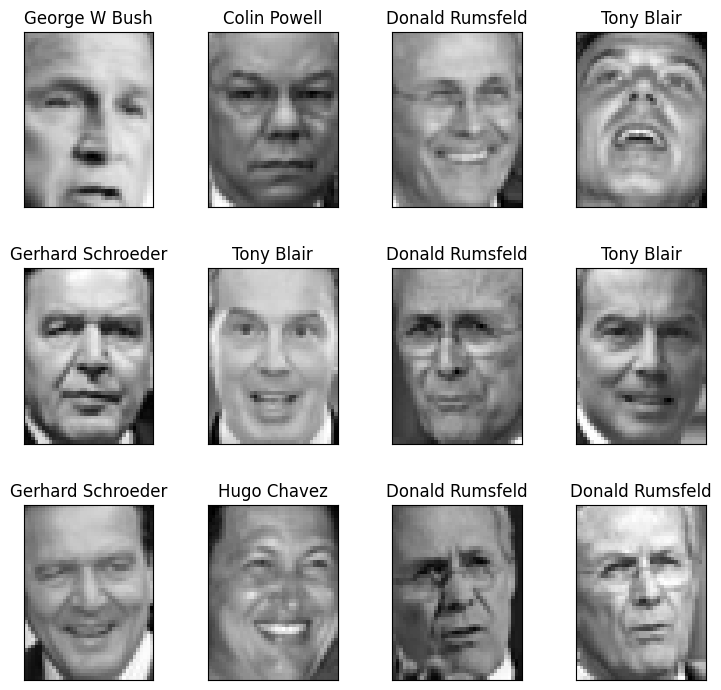

In [ ]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

def plot_gallery(images: npt.NDArray[np.floating], titles: list[str], h: int, w: int, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits."""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap="gray")
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

sample_faces = X_train[0:13].reshape((13, h, w))
face_titles = ["%s" % target_names[t] for t in y_train]
plot_gallery(sample_faces, face_titles, h, w)

### 📝 Task 1.3 Apply dimensionality reduction methods

Now, we can apply different dimensionality reduction methods to the input data. We will compare [Principal Component Analysis](https://scikit-learn.org/stable/modules/decomposition.html#pca) (PCA), [Non-Negative Matrix Factorisation](https://scikit-learn.org/stable/modules/decomposition.html#nmf) (NMF), and [Independent Component Analysis](https://scikit-learn.org/stable/modules/decomposition.html#ica) (ICA).

In [ ]:
from sklearn.decomposition import PCA, NMF, FastICA
from time import time

n_components = 150 # Number of components for dimensionality reduction

print("Extracting the top %d eigenfaces from %d faces" % (n_components, X_train.shape[0]))
t0 = time()
pca = PCA(n_components=n_components, svd_solver="randomized", whiten=True).fit(X_train)
print("done in %0.3fs" % (time() - t0))

eigenfaces = pca.components_.reshape((n_components, h, w))

t0 = time()
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("projecting the input data on the eigenfaces done in %0.3fs" % (time() - t0))

# NMF
print("Extracting the top %d NMF components from %d faces" % (n_components, X_train.shape[0]))
t0 = time()
nmf = NMF(n_components=n_components, random_state=42, init='nndsvda', tol=1e-3, max_iter=200).fit(X_train)
print("done in %0.3fs" % (time() - t0))

nmf_components = nmf.components_.reshape((n_components, h, w))

t0 = time()
X_train_nmf = nmf.transform(X_train)
X_test_nmf = nmf.transform(X_test)
print("projecting the input data on the NMF components done in %0.3fs" % (time() - t0))

# ICA
print("Extracting the top %d ICA components from %d faces" % (n_components, X_train.shape[0]))
t0 = time()
ica = FastICA(n_components=n_components, random_state=42, whiten="unit-variance").fit(X_train)
print("done in %0.3fs" % (time() - t0))

ica_components = ica.components_.reshape((n_components, h, w))

t0 = time()
X_train_ica = ica.transform(X_train)
X_test_ica = ica.transform(X_test)
print("projecting the input data on the ICA components done in %0.3fs" % (time() - t0))

Extracting the top 150 eigenfaces from 966 faces
done in 3.630s
projecting the input data on the eigenfaces done in 0.105s
Extracting the top 150 NMF components from 966 faces
done in 1.848s


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


projecting the input data on the NMF components done in 14.960s
Extracting the top 150 ICA components from 966 faces
done in 4.039s
projecting the input data on the ICA components done in 0.072s


### 📝 Task 1.4 Visualise results

We can now visualise the main components learned by each of the dimensionlity reduction methods we just trained. Each of them will have the same dimension as a face, so we feel free to reuse the `plot_gallery` functions that we previously wrote.

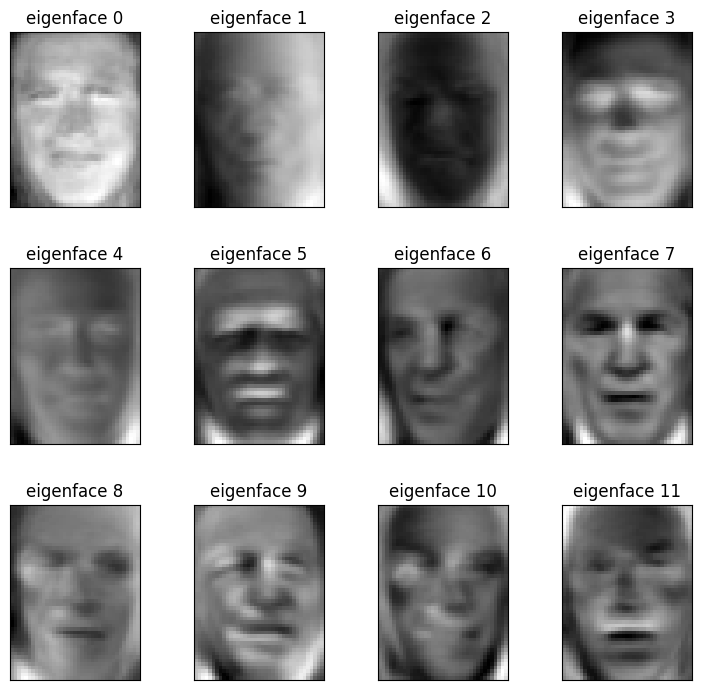

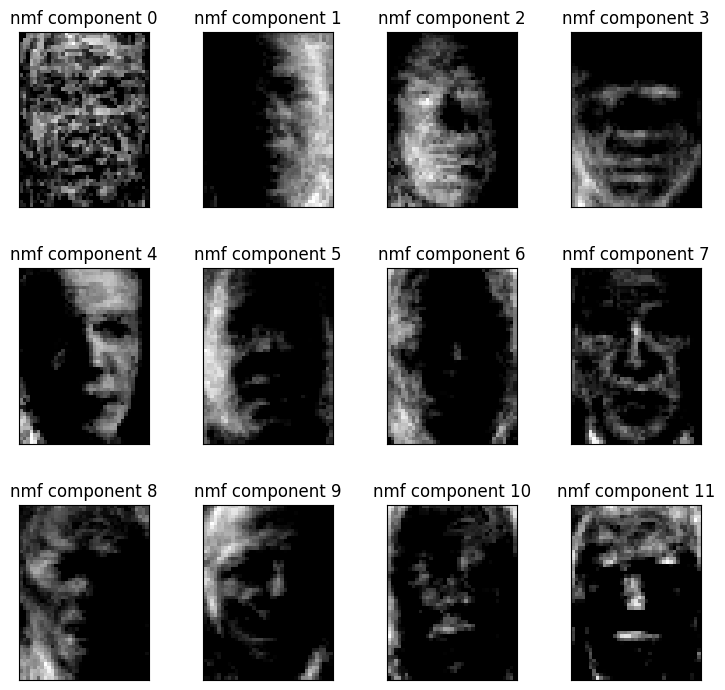

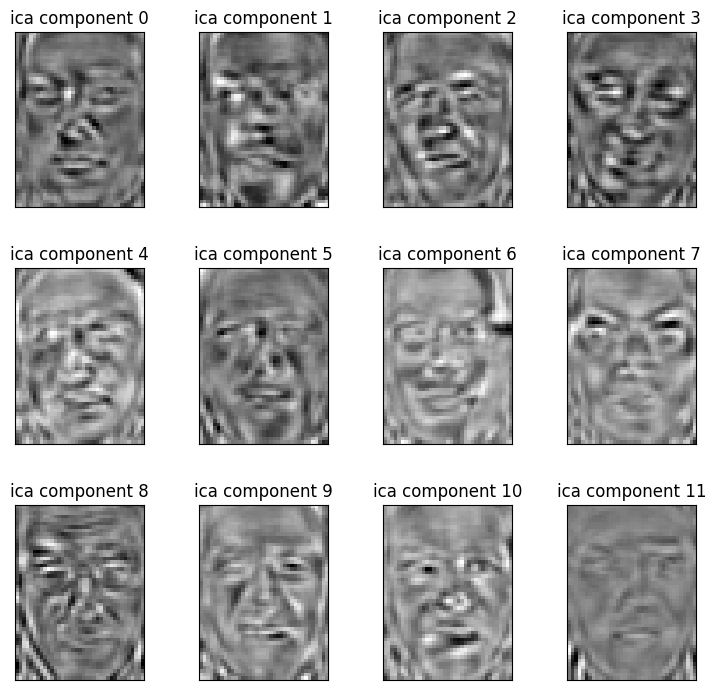

In [ ]:
# Visualize PCA components
recon_pca_titles = [f"eigenface {i}" for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, recon_pca_titles, h, w)

# Visualize NMF components
recon_nmf_titles = [f"nmf component {i}" for i in range(nmf_components.shape[0])]
plot_gallery(nmf_components, recon_nmf_titles, h, w)

# Visualize ICA components
recon_ica_titles = [f"ica component {i}" for i in range(ica_components.shape[0])]
plot_gallery(ica_components, recon_ica_titles, h, w)

### 📝 Task 1.5 Train SVM Classifier using the Components Extraced by the Different Methods and Evaluate

Before dimensionality reduction, each face was described by 1850 pixel brightness values.
After dimensionality reduction, each face is described by 50 numbers telling us how much of each eigenface it contains.

Finally, we train an SVM classifier to predict a person's name given a picture of their face. How does the classifier's performance change when using no dimensionality reduction compared to the methods trained above?

In [ ]:
from scipy.stats import loguniform
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

svm = SVC(kernel="rbf", class_weight="balanced", random_state=42)


====== Training SVM on Original Data data ======
Fitting 5 folds for each of 10 candidates, totalling 50 fits
done in 61.534s
Best estimator found by grid search:
SVC(C=np.float64(157.0297088405538), class_weight='balanced',
    gamma=np.float64(0.006251373574521752), random_state=42)
Predicting people's names on the test set
done in 0.483s
                   precision    recall  f1-score   support

     Ariel Sharon       0.60      0.69      0.64        13
     Colin Powell       0.77      0.85      0.81        60
  Donald Rumsfeld       0.77      0.63      0.69        27
    George W Bush       0.90      0.92      0.91       146
Gerhard Schroeder       0.80      0.80      0.80        25
      Hugo Chavez       0.91      0.67      0.77        15
       Tony Blair       0.82      0.78      0.80        36

         accuracy                           0.84       322
        macro avg       0.80      0.76      0.77       322
     weighted avg       0.84      0.84      0.83       322



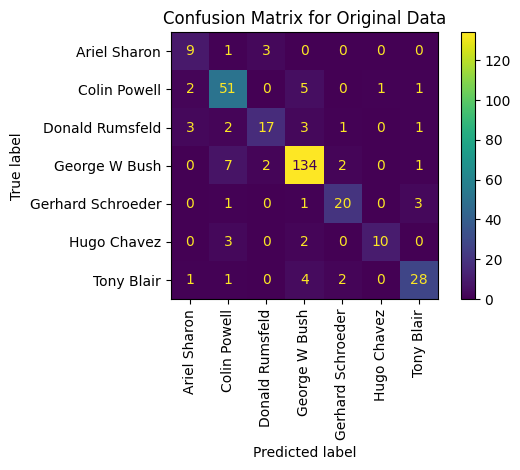


====== Training SVM on PCA Components data ======
Fitting 5 folds for each of 10 candidates, totalling 50 fits
done in 5.780s
Best estimator found by grid search:
SVC(C=np.float64(8.17949947521167), class_weight='balanced',
    gamma=np.float64(0.0037520558551242854), random_state=42)
Predicting people's names on the test set
done in 0.058s
                   precision    recall  f1-score   support

     Ariel Sharon       0.73      0.62      0.67        13
     Colin Powell       0.80      0.87      0.83        60
  Donald Rumsfeld       0.76      0.70      0.73        27
    George W Bush       0.88      0.96      0.92       146
Gerhard Schroeder       1.00      0.80      0.89        25
      Hugo Chavez       0.90      0.60      0.72        15
       Tony Blair       0.94      0.83      0.88        36

         accuracy                           0.86       322
        macro avg       0.86      0.77      0.81       322
     weighted avg       0.87      0.86      0.86       322



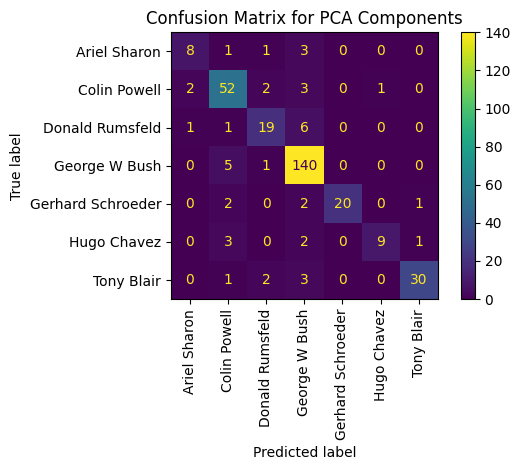


====== Training SVM on NMF Components data ======
Fitting 5 folds for each of 10 candidates, totalling 50 fits
done in 7.931s
Best estimator found by grid search:
SVC(C=np.float64(13.292918943162162), class_weight='balanced',
    gamma=np.float64(0.07114476009343425), random_state=42)
Predicting people's names on the test set
done in 0.063s
                   precision    recall  f1-score   support

     Ariel Sharon       0.10      0.38      0.16        13
     Colin Powell       0.25      0.33      0.28        60
  Donald Rumsfeld       0.43      0.11      0.18        27
    George W Bush       0.63      0.27      0.38       146
Gerhard Schroeder       0.16      0.52      0.24        25
      Hugo Chavez       0.18      0.20      0.19        15
       Tony Blair       0.30      0.17      0.21        36

         accuracy                           0.28       322
        macro avg       0.29      0.28      0.23       322
     weighted avg       0.43      0.28      0.30       322



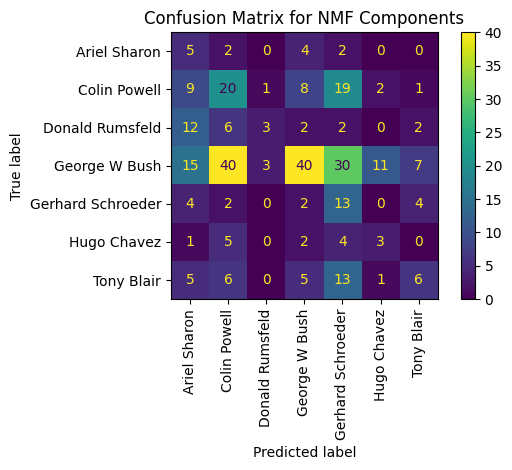


====== Training SVM on ICA Components data ======
Fitting 5 folds for each of 10 candidates, totalling 50 fits
done in 5.919s
Best estimator found by grid search:
SVC(C=np.float64(8.17949947521167), class_weight='balanced',
    gamma=np.float64(0.0037520558551242854), random_state=42)
Predicting people's names on the test set
done in 0.057s
                   precision    recall  f1-score   support

     Ariel Sharon       0.82      0.69      0.75        13
     Colin Powell       0.78      0.87      0.82        60
  Donald Rumsfeld       0.68      0.63      0.65        27
    George W Bush       0.88      0.95      0.91       146
Gerhard Schroeder       0.91      0.80      0.85        25
      Hugo Chavez       0.89      0.53      0.67        15
       Tony Blair       0.93      0.78      0.85        36

         accuracy                           0.85       322
        macro avg       0.84      0.75      0.79       322
     weighted avg       0.85      0.85      0.84       322



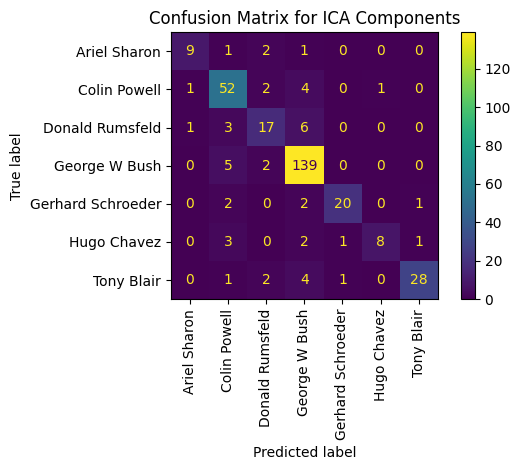

In [ ]:
param_grid = {
    'C': loguniform(1e0, 1e3),
    'gamma': loguniform(1e-4, 1e-1),
}

# Helper function to train and evaluate SVM
def train_and_evaluate_svm(X_train_data, X_test_data, y_train_data, y_test_data, name):
    print(f"\n====== Training SVM on {name} data ======")
    t0 = time()
    clf = RandomizedSearchCV(svm, param_grid, n_iter=10, random_state=42, n_jobs=-1, verbose=1)
    clf = clf.fit(X_train_data, y_train_data)
    print("done in %0.3fs" % (time() - t0))
    print(f"Best estimator found by grid search:\n{clf.best_estimator_}")

    print("Predicting people's names on the test set")
    t0 = time()
    y_pred = clf.predict(X_test_data)
    print("done in %0.3fs" % (time() - t0))

    print(classification_report(y_test_data, y_pred, target_names=target_names))

    # Plotting the confusion matrix
    display_labels = target_names[unique_labels(y_test_data, y_pred)]
    ConfusionMatrixDisplay.from_estimator(
        clf, X_test_data, y_test_data, display_labels=display_labels, xticks_rotation="vertical"
    )
    plt.title(f'Confusion Matrix for {name}')
    plt.tight_layout()
    plt.show()

from sklearn.utils.multiclass import unique_labels

# Train SVM on Original Data
train_and_evaluate_svm(X_train, X_test, y_train, y_test, "Original Data")

# Train SVM on PCA Components
train_and_evaluate_svm(X_train_pca, X_test_pca, y_train, y_test, "PCA Components")

# Train SVM on NMF Components
train_and_evaluate_svm(X_train_nmf, X_test_nmf, y_train, y_test, "NMF Components")

# Train SVM on ICA Components
train_and_evaluate_svm(X_train_ica, X_test_ica, y_train, y_test, "ICA Components")


### 🗣 Discuss:
- What are the differences in how PCA, NMF, and ICA capture features.
- How do these differences affect the performance of the SVM classifier.

**Differences in how PCA, NMF, and ICA capture features:**

PCA extracts orthogonal directions that capture the maximum variance in the data, producing global features that represent overall patterns in images. ICA instead finds statistically independent components, often capturing localized signals such as edges or texture patterns. NMF decomposes the data into non-negative, additive components, leading to parts-based representations where images are described as combinations of localized features such as facial parts. As a result, PCA focuses on global variance, ICA emphasizes independent signals, and NMF highlights interpretable but localized structures.

**Effect on SVM classifier performance:**

These differences directly influence how well the extracted features separate classes for classification. PCA and ICA preserve important structural information in the images, enabling the SVM to construct effective decision boundaries and achieve high accuracy. In contrast, NMF focuses on individual parts rather than the overall structure of the face, which reduces the discriminative power of the features. Consequently, SVM performance remains strong with PCA and ICA representations but drops significantly when using NMF features.

### Task 1.6 **Extension**: use a deep learning-based autoencoder to learn the embeddings

- non-linear
- unsupervised


<div align="center">
<img src="https://developers.google.com/machine-learning/clustering/images/autoencoder.png?hl=fr" width="500">
</div>

In [ ]:
n_components = 150

In [ ]:
# Scale to [0,1] using train stats
x_min = X_train.min()
x_max = X_train.max()

X_train_ae = (X_train - x_min) / (x_max - x_min + 1e-8)
X_test_ae  = (X_test  - x_min) / (x_max - x_min + 1e-8)

Task: Define the Autoencoder
> Define an autoencoder with an encoder that compresses the input to a latent representation and a decoder that reconstructs the input from this representation

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        # Encoder: compress input into latent representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # Decoder: reconstruct input from latent representation
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()   # useful if image pixels are normalized to [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

Autoencoder training and setup (nothing to do here).
> If you want, you can change the number of epochs

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Autoencoder(input_dim=X_train.shape[1],
                    latent_dim=n_components).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_tensor = torch.tensor(X_train_ae, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor),
                          batch_size=128,
                          shuffle=True)

model.train()
for epoch in range(5):
    total_loss = 0
    for (xb,) in train_loader:
        xb = xb.to(device)

        optimizer.zero_grad()
        recon = model(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    print(f"Epoch {epoch+1:02d} | Recon Loss: {total_loss / len(train_loader.dataset):.5f}")

Epoch 01 | Recon Loss: 0.02705
Epoch 02 | Recon Loss: 0.02230
Epoch 03 | Recon Loss: 0.02147
Epoch 04 | Recon Loss: 0.02033
Epoch 05 | Recon Loss: 0.01880


Once the autoencoder is trained, obtain the train and test embeddings from the encoder and use them to train and evaluate the same SVM classifier as in Task 1.5.

In [ ]:
model.eval()

with torch.no_grad():
    Z_train = model.encoder(
        torch.tensor(X_train_ae, dtype=torch.float32).to(device)
    ).cpu().numpy()

    Z_test = model.encoder(
        torch.tensor(X_test_ae, dtype=torch.float32).to(device)
    ).cpu().numpy()

print(Z_train.shape)

(966, 150)


Train and evaluate an SVM using AE-learned embeddings.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train SVM on latent features from Autoencoder
svm = SVC(kernel="rbf", C=10, gamma="scale")   # good default; you can tune C/gamma
svm.fit(Z_train_s, y_train)

# Predict + evaluate
y_pred = svm.predict(Z_test_s)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.562111801242236

Classification report:
               precision    recall  f1-score   support

           0       0.20      0.08      0.11        13
           1       0.54      0.52      0.53        60
           2       0.50      0.30      0.37        27
           3       0.58      0.88      0.70       146
           4       0.75      0.12      0.21        25
           5       0.29      0.13      0.18        15
           6       0.57      0.22      0.32        36

    accuracy                           0.56       322
   macro avg       0.49      0.32      0.35       322
weighted avg       0.55      0.56      0.51       322


Confusion matrix:
 [[  1   5   1   6   0   0   0]
 [  1  31   2  26   0   0   0]
 [  1   5   8  11   0   0   2]
 [  2   6   2 128   1   4   3]
 [  0   3   2  15   3   1   1]
 [  0   3   0  10   0   2   0]
 [  0   4   1  23   0   0   8]]


**What do you observe in terms of performance?**

Training an SVM on the autoencoder latent representations achieved an accuracy of 56%. While this indicates that the latent space captures some useful structure of the data, the classifier struggles with minority classes and frequently predicts the majority class (class 3). This suggests that the autoencoder representation is optimized for reconstruction rather than class separation, leading to overlapping class clusters in the latent space.

## 👩‍💻 Part 2: OASIS dataset: Cross decomposition methods

In this part, you will learn how to apply cross decomposition methods such as CCA and PLSSVD to find the fundamental relations (or latent dimensions) between two matrices (X and Y) that represent different views of the same data.

We will use the Open Access Series of Imaging Studies (OASIS) dataset, which contains brain Magnetic Resonance Images (MRI) (view 1) and clinical assessments (view 2) of 100 subjects aged 18 to 96. The brain images have been summarized into 116 Regions of Interest (ROIs) using the Automated Anatomical Labeling (AAL) atlas (https://www.gin.cnrs.fr/en/tools/aal/). The clinical data consist of tabular data including gender, age, education and two clinical questionnairs, the mini mental state examination (MMSE) and the clinical dementia rating (CDR). The goal is to explore how these two views are related.

It is important to note that there are 2 groups in the OASIS data: healthy subjects, and those with dementia. The `OASIS_labels.csv` file contains the label for each subject.

### Import libraries and load data

First, we need to import some libraries and load the data from CSV files.

In [ ]:
import pandas as pd

labels = pd.read_csv("./OASIS_labels.csv")
brain_roi = pd.read_csv("./OASIS_view1_ROI.csv")
clinical = pd.read_csv("./OASIS_view2_clinical.csv")
roi_names = pd.read_csv("./AAL_ROI_names.csv", header=None).squeeze()

### Data preprocessing

Next, we need to do some preprocessing on the data. We will drop some columns that are not relevant for our analysis, such as subject ID, handness, etc. We will also normalize each view by subtracting its mean and dividing by its standard deviation.

CCA is about corelation, and PLSSVD is about covariance between the two datasets here, brain and clinical.

In [ ]:
from sklearn.preprocessing import StandardScaler

brain_roi = brain_roi.drop(["Subject ID"], axis=1)
clinical = clinical.drop(["Subject ID"], axis=1)

# One-hot encode the "Gender" column and drop the first column to avoid multicollinearity
clinical = pd.get_dummies(clinical, columns=["Gender"], drop_first=True)

# Fill nans with mean values
brain_roi = brain_roi.fillna(brain_roi.mean(numeric_only=True))
clinical = clinical.fillna(clinical.mean(numeric_only=True))

brain_roi.columns = roi_names

# Convert labels to numbers before the split
label_dict = {"Demented": 0, "Nondemented": 1}
labels["Group"] = labels["Group"].map(label_dict)

# Split the data and labels into training and testing sets
train_brain_roi, test_brain_roi, train_clinical, test_clinical, train_labels, test_labels = train_test_split(
    brain_roi, clinical, labels["Group"], test_size=0.3, random_state=42)

# Apply StandardScaler separately to training and testing sets to avoid data leakage
scaler_brain = StandardScaler()
train_brain_roi = scaler_brain.fit_transform(train_brain_roi)
test_brain_roi = scaler_brain.transform(test_brain_roi)

scaler_clinical = StandardScaler()
train_clinical = scaler_clinical.fit_transform(train_clinical)
test_clinical = scaler_clinical.transform(test_clinical)

In [ ]:
brain_roi

,Precentral_L,Precentral_R,Frontal_Sup_L,Frontal_Sup_R,Frontal_Sup_Orb_L,Frontal_Sup_Orb_R,Frontal_Mid_L,Frontal_Mid_R,Frontal_Mid_Orb_L,Frontal_Mid_Orb_R,...,Cerebelum_10_L,Cerebelum_10_R,Vermis_1_2,Vermis_3,Vermis_4_5,Vermis_6,Vermis_7,Vermis_8,Vermis_9,Vermis_10
0,0.328376,0.310736,0.331466,0.365400,0.473319,0.513658,0.365515,0.426603,0.435912,0.491478,...,0.158964,0.117107,0.343077,0.332691,0.476891,0.525261,0.610925,0.692715,0.666304,0.212833
1,0.265462,0.284931,0.280695,0.311896,0.317296,0.329173,0.288063,0.330815,0.278311,0.296520,...,0.149029,0.131028,0.329705,0.320142,0.462999,0.478867,0.563096,0.683033,0.587780,0.198033
2,0.254751,0.257339,0.292834,0.264672,0.398141,0.351934,0.317767,0.328207,0.358854,0.375535,...,0.137343,0.118622,0.379502,0.330435,0.380093,0.441531,0.554831,0.641267,0.561768,0.213696
3,0.280047,0.297505,0.291329,0.323008,0.429695,0.414882,0.343897,0.357219,0.412683,0.423509,...,0.127153,0.134607,0.309793,0.273754,0.345968,0.414761,0.449908,0.512534,0.506002,0.157815
4,0.247047,0.241039,0.245281,0.240963,0.348234,0.325550,0.276698,0.275589,0.355991,0.335164,...,0.132554,0.109551,0.288043,0.255369,0.305809,0.338685,0.404975,0.449699,0.381659,0.154141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.283958,0.283804,0.274866,0.275195,0.436282,0.429009,0.310347,0.371561,0.392171,0.405194,...,0.168741,0.150855,0.355952,0.340494,0.468567,0.547288,0.661266,0.681692,0.561343,0.204061
96,0.219749,0.229720,0.231304,0.236867,0.311941,0.290046,0.240077,0.255363,0.284920,0.335230,...,0.129547,0.129192,0.367391,0.337985,0.400780,0.429753,0.546856,0.561667,0.460930,0.187182
97,0.260072,0.245813,0.275967,0.263345,0.363978,0.356836,0.294807,0.303855,0.345023,0.368028,...,0.100847,0.105040,0.311794,0.314821,0.411738,0.452949,0.534124,0.613260,0.545518,0.197639
98,0.307017,0.306713,0.242192,0.303062,0.371719,0.372836,0.327543,0.367935,0.379560,0.388705,...,0.104170,0.122919,0.292791,0.264992,0.319118,0.369786,0.451831,0.471996,0.432581,0.164918


In [ ]:
clinical

,Age,EDUC,MMSE,CDR,Gender_M
0,87,14,27,0.0,True
1,80,12,28,0.0,True
2,71,16,28,0.5,True
3,66,12,30,0.5,False
4,81,12,30,0.0,False
...,...,...,...,...,...
95,68,14,26,0.0,True
96,74,12,26,0.5,False
97,66,13,30,0.0,False
98,72,16,24,0.5,False


### Cross decomposition methods

Now we are ready to apply cross decomposition methods to find the relations between the two views. We will use three methods: CCA, regularised CCA and PLSSVD.

CCA finds linear combinations of X and Y that have maximum correlation. It can be seen as a generalization of PCA for two sets of variables.

Regularised CCA adds a regularisation term to prevent overfitting on the training set.

PLSSVD finds linear combinations of X and Y that have maximum covariance. It can be seen as a generalization of SVD for two sets of variables.

For both methods, we need to specify the number of components that we want to extract from each view. This parameter controls the dimensionality of the latent space.

We will use n_components=2 for both methods. You can try different values later and see how they affect the results.

For further comparison, apply PCA to the brain_roi data with 2 components in order to see if combining the modalities changes the latent space.

### Task 2.1 - Apply CCA to the brain and clinical dataset and plot the weights for the two first CCA components (brain and clinical)

We will use [`cca-zoo`](https://cca-zoo.readthedocs.io/en/latest/#) to carry out the calculations. It's a library which offers support for many different algorithms, including a regularised version of CCA which is not present in `sklearn`.

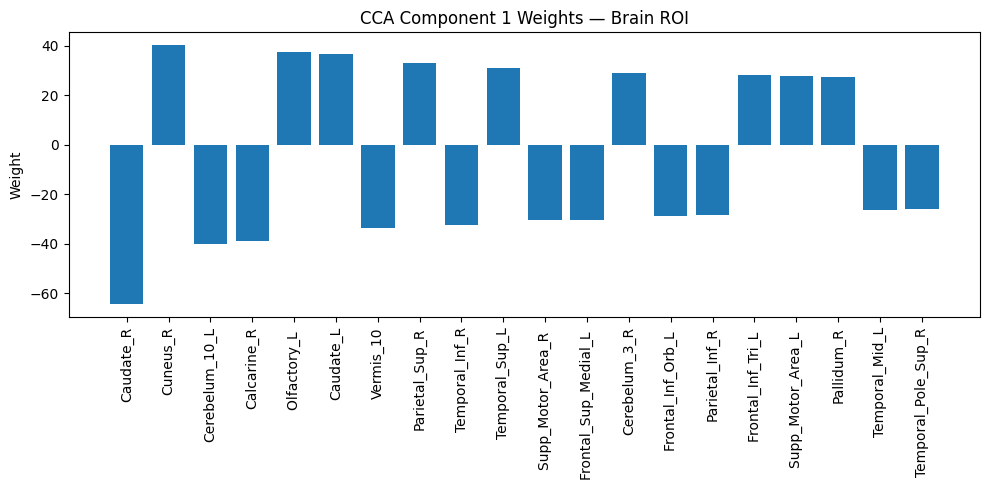

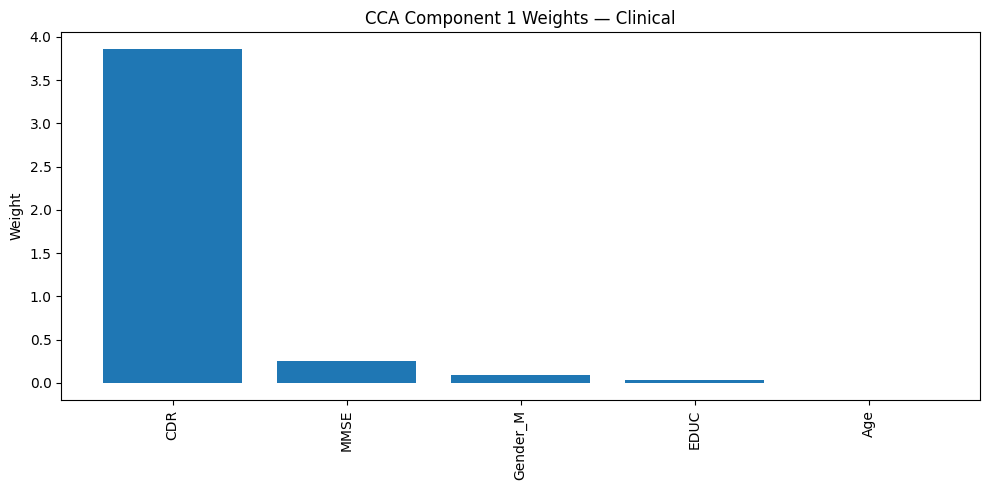

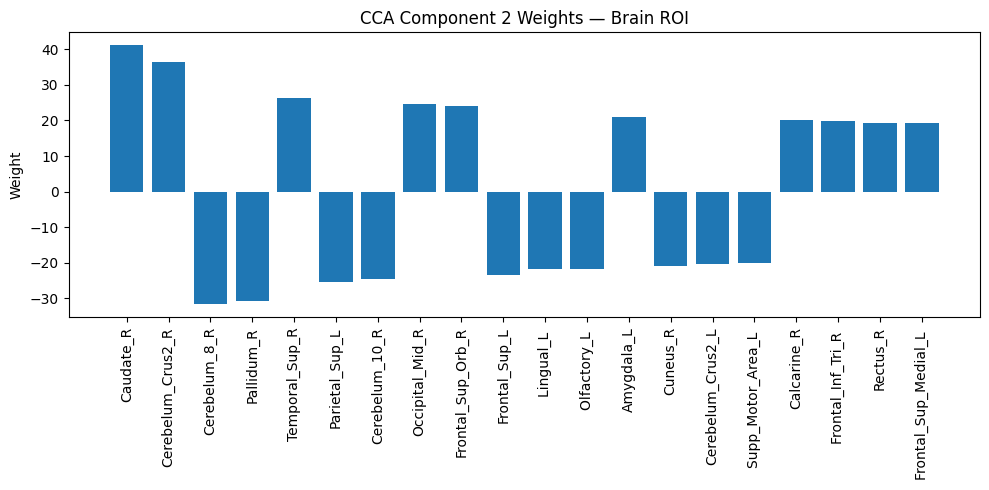

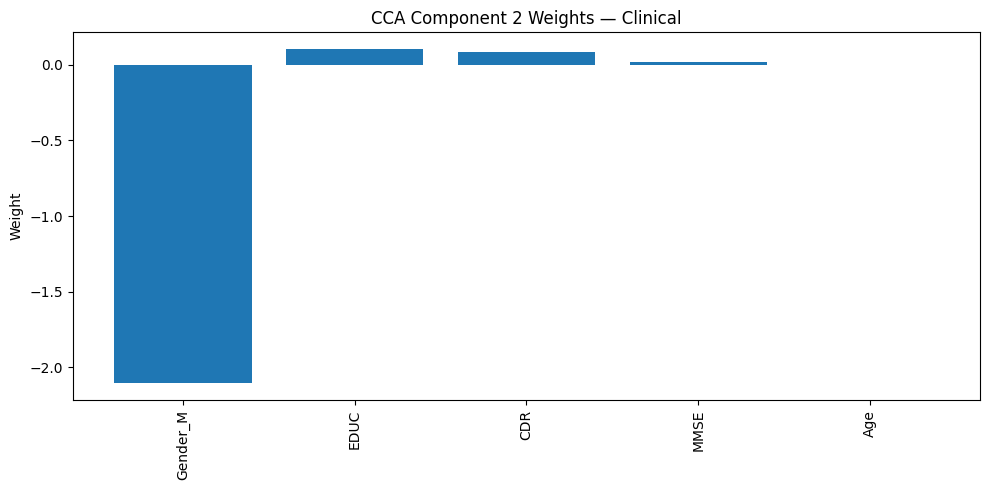

In [ ]:
from cca_zoo.linear import CCA
from cca_zoo._base import _BaseModel

# Convert to numpy, keep feature names if DataFrames
if hasattr(brain_roi, "values"):
    X = brain_roi.values
    brain_names = list(brain_roi.columns)
else:
    X = np.asarray(brain_roi)
    brain_names = [f"brain_{i}" for i in range(X.shape[1])]

if hasattr(clinical, "values"):
    Y = clinical.values
    clinical_names = list(clinical.columns)
else:
    Y = np.asarray(clinical)
    clinical_names = [f"clinical_{i}" for i in range(Y.shape[1])]

# Fit CCA
cca: _BaseModel = CCA(latent_dimensions=2, random_state=42)
cca.fit((X, Y))

# Extract weights (one matrix per view): shape (n_features_view, n_components)
W_brain, W_clinical = cca.weights_

def plot_component_weights(w, feature_names, title, top_k=20):
    """
    Bar plot of weights for one component (shows top_k by absolute value).
    """
    w = np.asarray(w).ravel()
    idx = np.argsort(np.abs(w))[::-1][:min(top_k, len(w))]
    w_top = w[idx]
    names_top = [feature_names[i] for i in idx]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(w_top)), w_top)
    plt.xticks(range(len(w_top)), names_top, rotation=90)
    plt.title(title)
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.show()

# Plot weights for the first two CCA components for both views
for comp in [0, 1]:
    plot_component_weights(
        W_brain[:, comp],
        brain_names,
        title=f"CCA Component {comp+1} Weights — Brain ROI",
        top_k=20
    )
    plot_component_weights(
        W_clinical[:, comp],
        clinical_names,
        title=f"CCA Component {comp+1} Weights — Clinical",
        top_k=20
    )

### Task 2.2 -  Plot the CCA latent space for the top 2 components

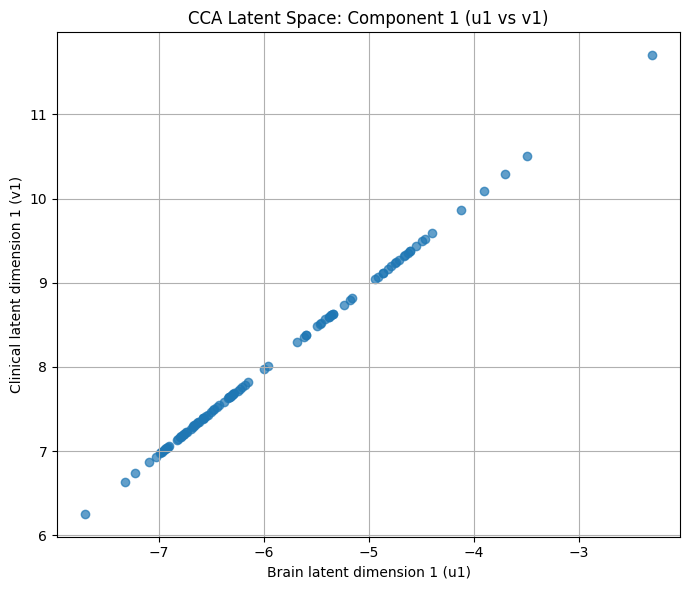

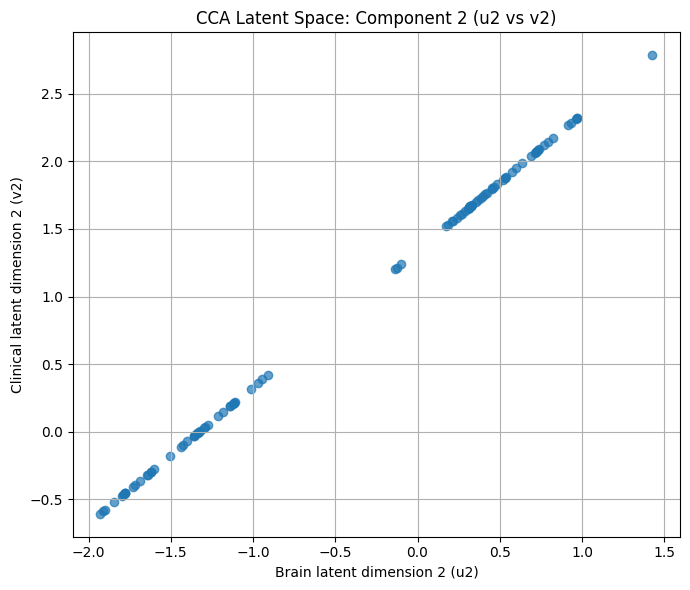

In [ ]:
# Project the data into the CCA latent space
Z_brain, Z_clinical = cca.transform((X, Y))

#  Plot Component 1: Brain dim 1 vs Clinical dim 1
plt.figure(figsize=(7, 6))
plt.scatter(Z_brain[:, 0], Z_clinical[:, 0], alpha=0.7)
plt.xlabel("Brain latent dimension 1 (u1)")
plt.ylabel("Clinical latent dimension 1 (v1)")
plt.title("CCA Latent Space: Component 1 (u1 vs v1)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Component 2: Brain dim 2 vs Clinical dim 2
plt.figure(figsize=(7, 6))
plt.scatter(Z_brain[:, 1], Z_clinical[:, 1], alpha=0.7)
plt.xlabel("Brain latent dimension 2 (u2)")
plt.ylabel("Clinical latent dimension 2 (v2)")
plt.title("CCA Latent Space: Component 2 (u2 vs v2)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 2.3 - Show the same plots, but obtained by applying regularised CCA to the brain and clinical dataset

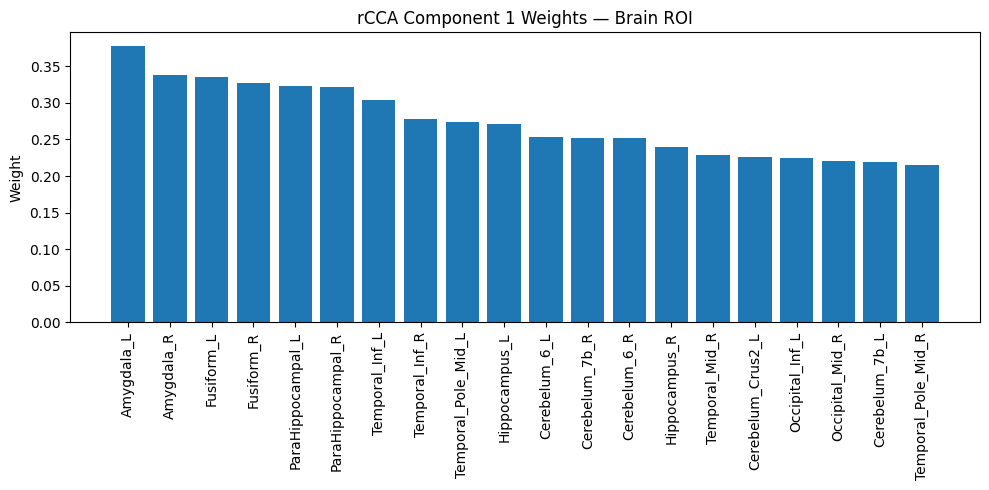

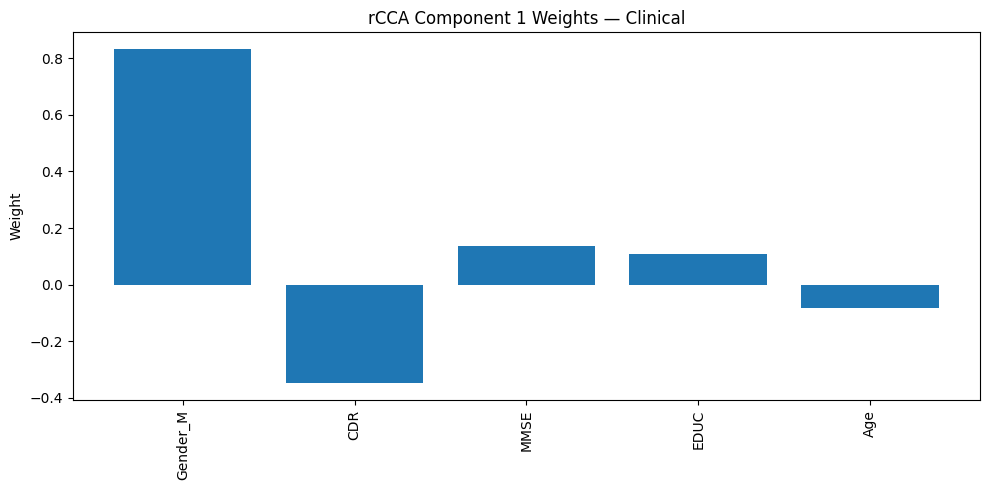

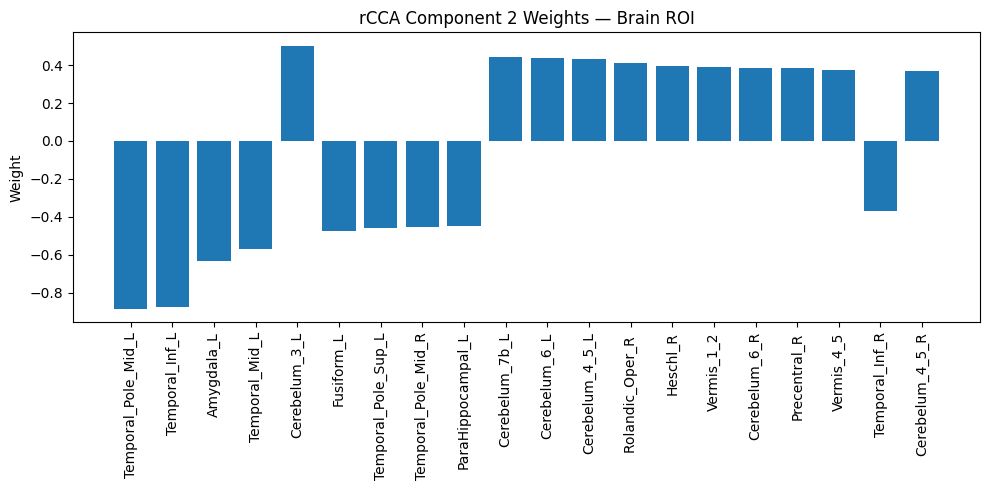

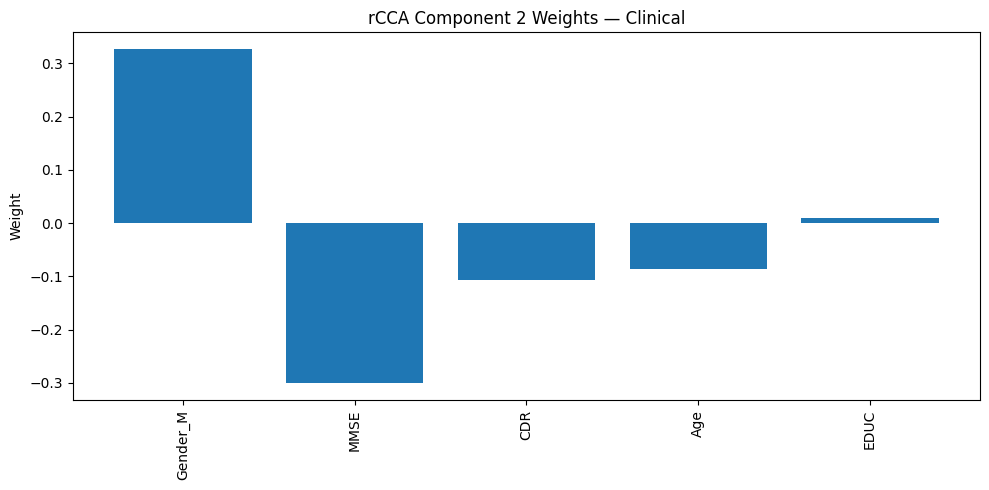

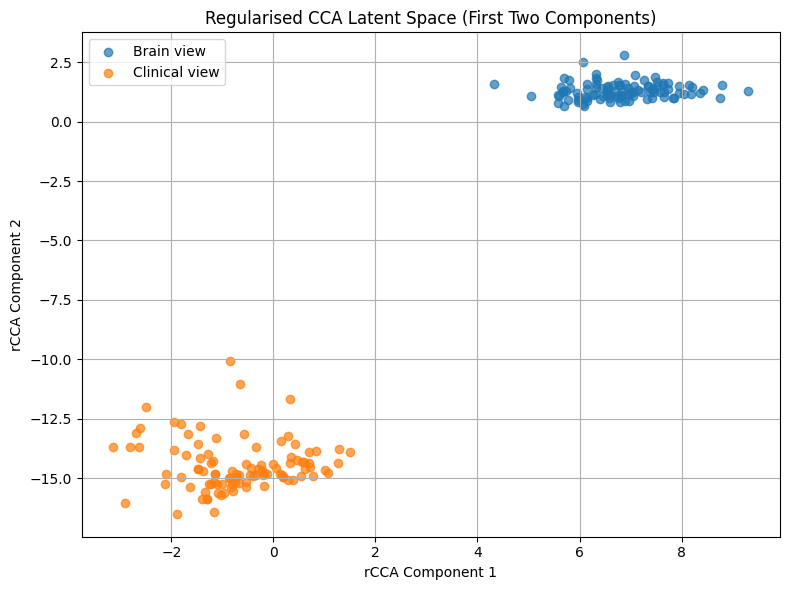

In [ ]:
from cca_zoo.linear import rCCA

rcca = rCCA(latent_dimensions=2, c=[0.1, 0.1], random_state=42)
rcca.fit((X, Y))

# Extract weights
W_brain_r, W_clinical_r = rcca.weights_

def plot_component_weights(w, feature_names, title, top_k=20):
    w = np.asarray(w).ravel()
    idx = np.argsort(np.abs(w))[::-1][:min(top_k, len(w))]
    w_top = w[idx]
    names_top = [feature_names[i] for i in idx]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(w_top)), w_top)
    plt.xticks(range(len(w_top)), names_top, rotation=90)
    plt.title(title)
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.show()

# Plot weights for first two components (brain + clinical)
for comp in [0, 1]:
    plot_component_weights(
        W_brain_r[:, comp],
        brain_names,
        title=f"rCCA Component {comp+1} Weights — Brain ROI",
        top_k=20
    )
    plot_component_weights(
        W_clinical_r[:, comp],
        clinical_names,
        title=f"rCCA Component {comp+1} Weights — Clinical",
        top_k=20
    )

# Plot latent space (first two components)
Z_brain_r, Z_clinical_r = rcca.transform((X, Y))

plt.figure(figsize=(8, 6))
plt.scatter(Z_brain_r[:, 0], Z_brain_r[:, 1], alpha=0.7, label="Brain view")
plt.scatter(Z_clinical_r[:, 0], Z_clinical_r[:, 1], alpha=0.7, label="Clinical view")
plt.xlabel("rCCA Component 1")
plt.ylabel("rCCA Component 2")
plt.title("Regularised CCA Latent Space (First Two Components)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 2.4 - Show the same plots, but obtained by applying PLSSVD to the brain and clinical dataset

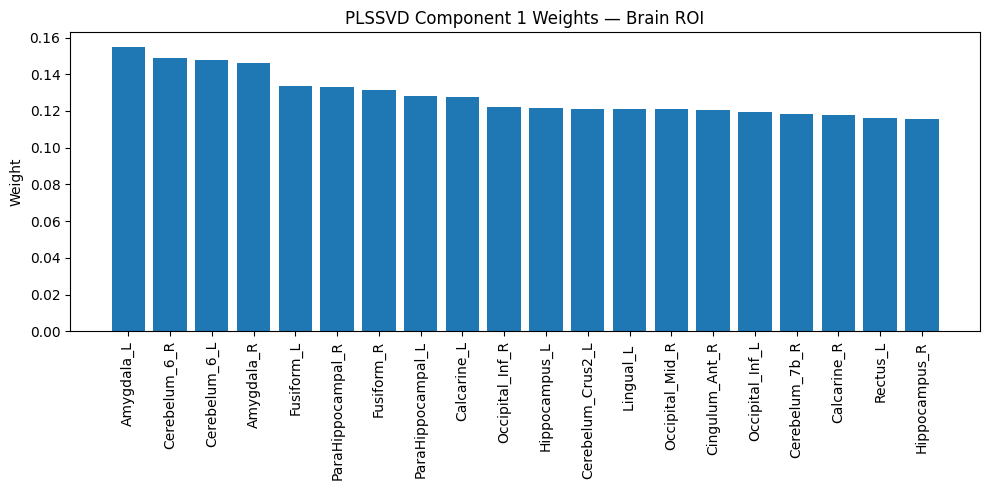

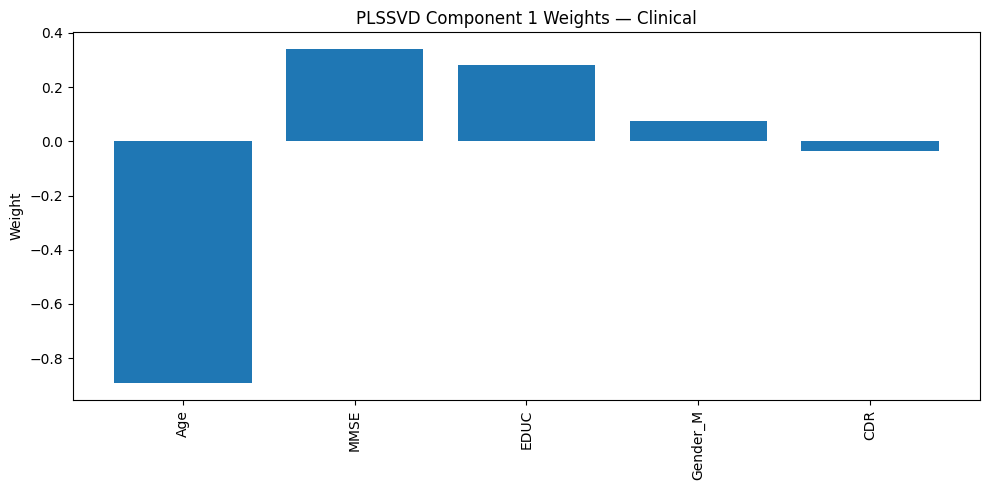

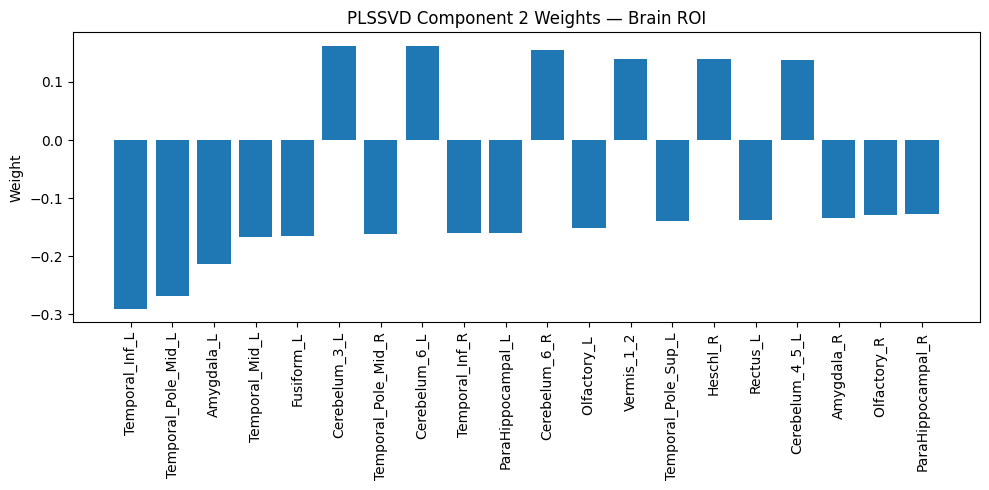

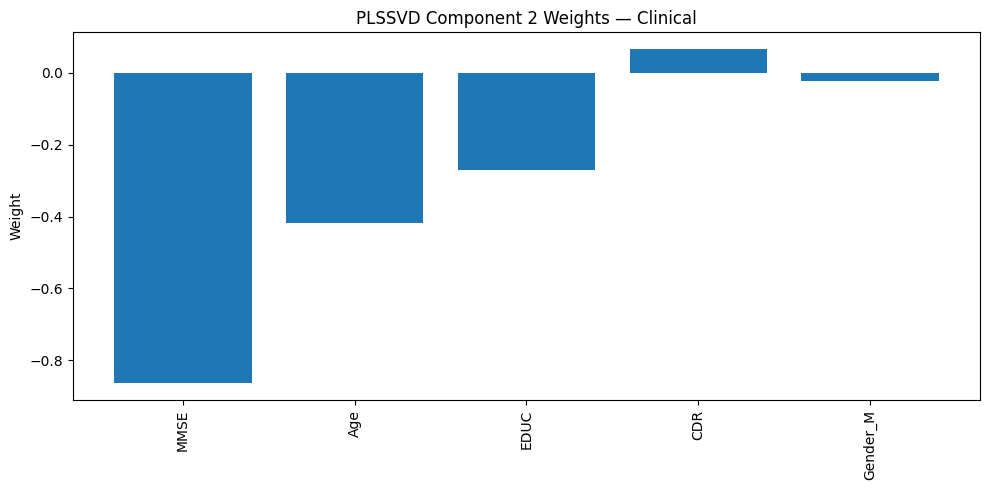

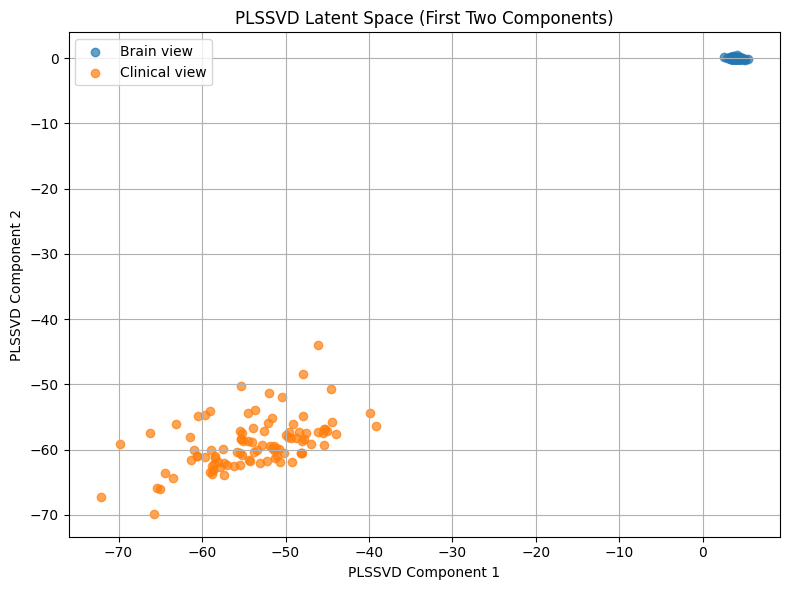

In [ ]:
from cca_zoo.linear import PLS

# Fit PLSSVD (2 components)
pls = PLS(latent_dimensions=2, random_state=42)
pls.fit((X, Y))

# Extract weights/loadings
W_brain_p, W_clinical_p = pls.weights_

def plot_component_weights(w, feature_names, title, top_k=20):
    w = np.asarray(w).ravel()
    idx = np.argsort(np.abs(w))[::-1][:min(top_k, len(w))]
    w_top = w[idx]
    names_top = [feature_names[i] for i in idx]

    plt.figure(figsize=(10, 5))
    plt.bar(range(len(w_top)), w_top)
    plt.xticks(range(len(w_top)), names_top, rotation=90)
    plt.title(title)
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.show()

# Plot weights for first two components (brain + clinical)
for comp in [0, 1]:
    plot_component_weights(
        W_brain_p[:, comp],
        brain_names,
        title=f"PLSSVD Component {comp+1} Weights — Brain ROI",
        top_k=20
    )
    plot_component_weights(
        W_clinical_p[:, comp],
        clinical_names,
        title=f"PLSSVD Component {comp+1} Weights — Clinical",
        top_k=20
    )

# Plot latent space (first two components)
Z_brain_p, Z_clinical_p = pls.transform((X, Y))

plt.figure(figsize=(8, 6))
plt.scatter(Z_brain_p[:, 0], Z_brain_p[:, 1], alpha=0.7, label="Brain view")
plt.scatter(Z_clinical_p[:, 0], Z_clinical_p[:, 1], alpha=0.7, label="Clinical view")
plt.xlabel("PLSSVD Component 1")
plt.ylabel("PLSSVD Component 2")
plt.title("PLSSVD Latent Space (First Two Components)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Task 2.5 - Now apply PCA to the brain and clinical data idependently and plot both:
- The first two PCA components
- The PCA latent space for the two first components

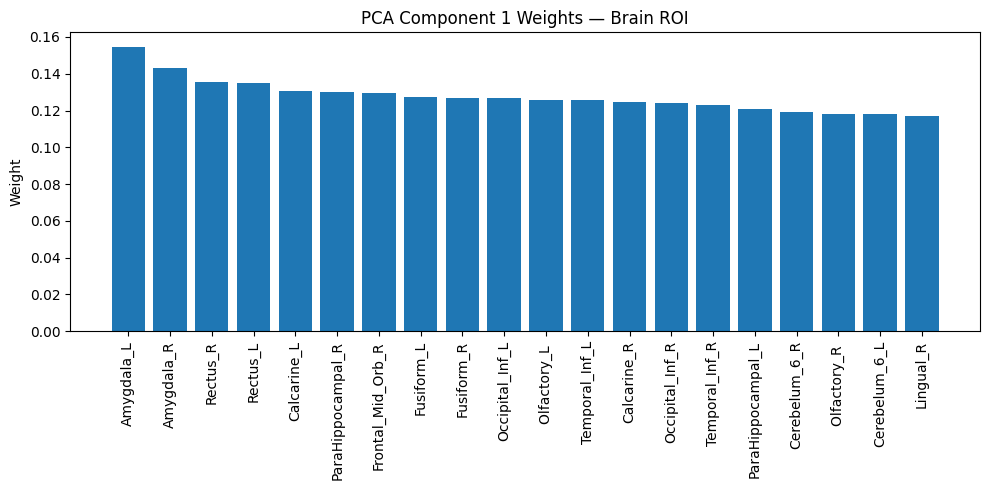

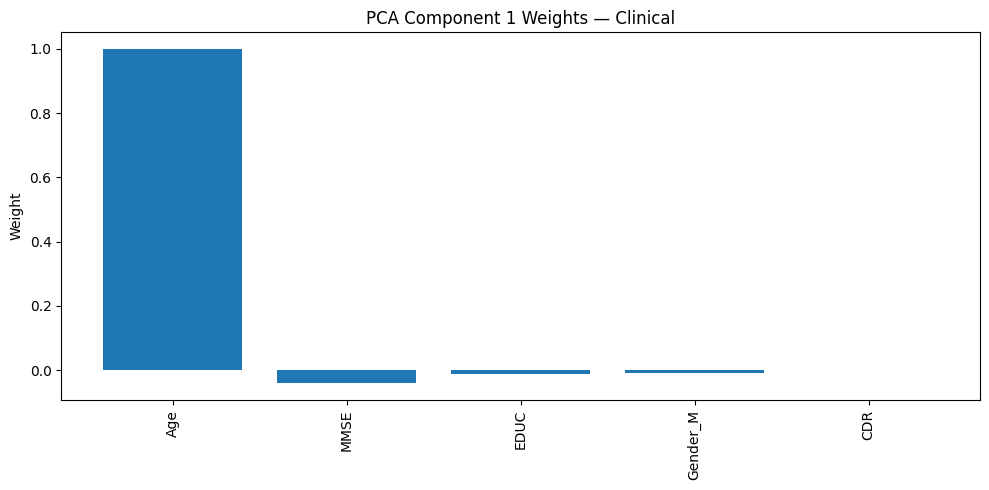

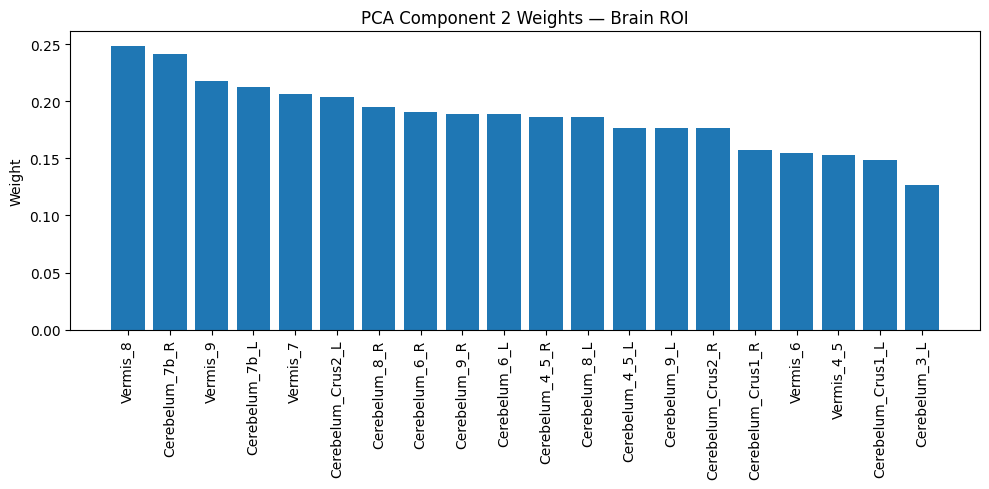

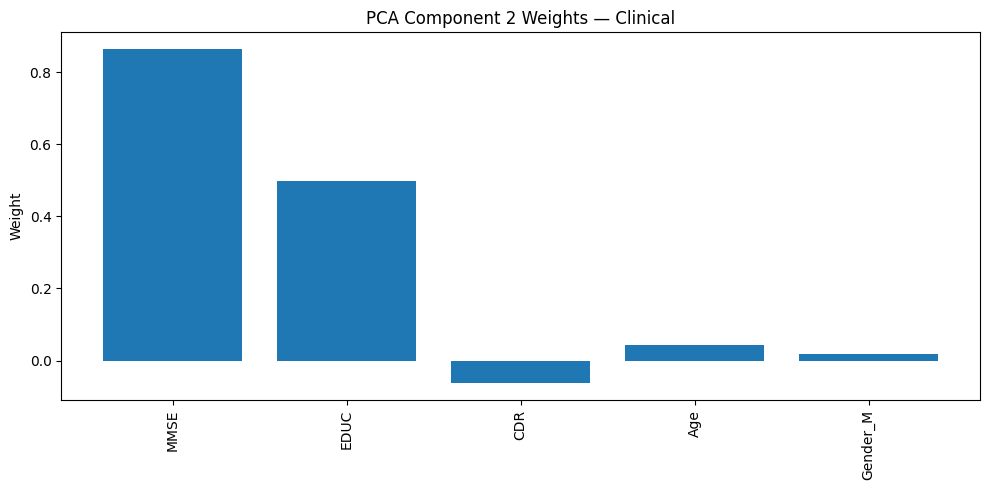

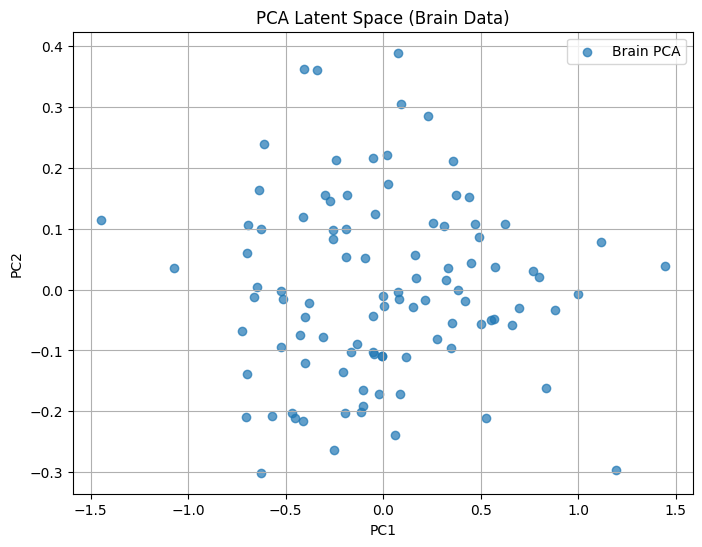

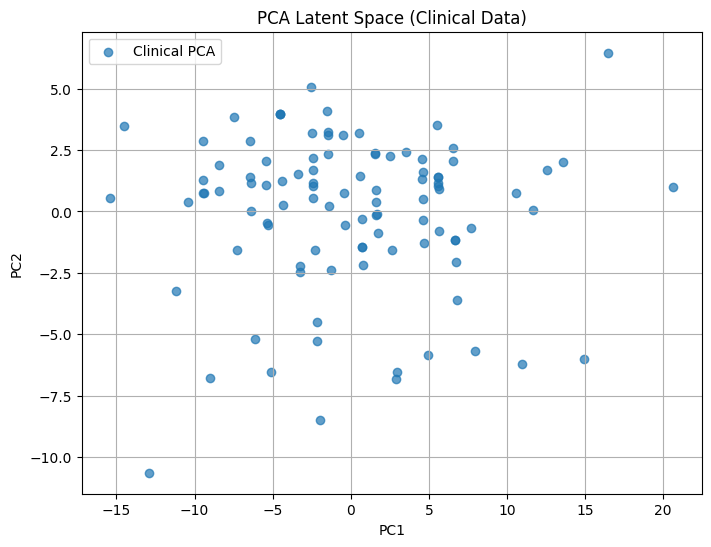

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Apply PCA independently
pca_brain = PCA(n_components=2, random_state=42)
pca_clinical = PCA(n_components=2, random_state=42)

Z_brain_pca = pca_brain.fit_transform(X)
Z_clinical_pca = pca_clinical.fit_transform(Y)

W_brain_pca = pca_brain.components_
W_clinical_pca = pca_clinical.components_

#  Function to plot component weights
def plot_component_weights(w, feature_names, title, top_k=20):
    w = np.asarray(w).ravel()
    idx = np.argsort(np.abs(w))[::-1][:min(top_k, len(w))]
    w_top = w[idx]
    names_top = [feature_names[i] for i in idx]

    plt.figure(figsize=(10,5))
    plt.bar(range(len(w_top)), w_top)
    plt.xticks(range(len(w_top)), names_top, rotation=90)
    plt.title(title)
    plt.ylabel("Weight")
    plt.tight_layout()
    plt.show()

# Plot PCA component weights
for comp in [0,1]:
    plot_component_weights(
        W_brain_pca[comp],
        brain_names,
        f"PCA Component {comp+1} Weights — Brain ROI"
    )

    plot_component_weights(
        W_clinical_pca[comp],
        clinical_names,
        f"PCA Component {comp+1} Weights — Clinical"
    )

# Plot PCA latent spaces
plt.figure(figsize=(8,6))
plt.scatter(Z_brain_pca[:,0], Z_brain_pca[:,1], alpha=0.7, label="Brain PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Latent Space (Brain Data)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(Z_clinical_pca[:,0], Z_clinical_pca[:,1], alpha=0.7, label="Clinical PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Latent Space (Clinical Data)")
plt.legend()
plt.grid(True)
plt.show()

#### Plotting PCA components (brain data)

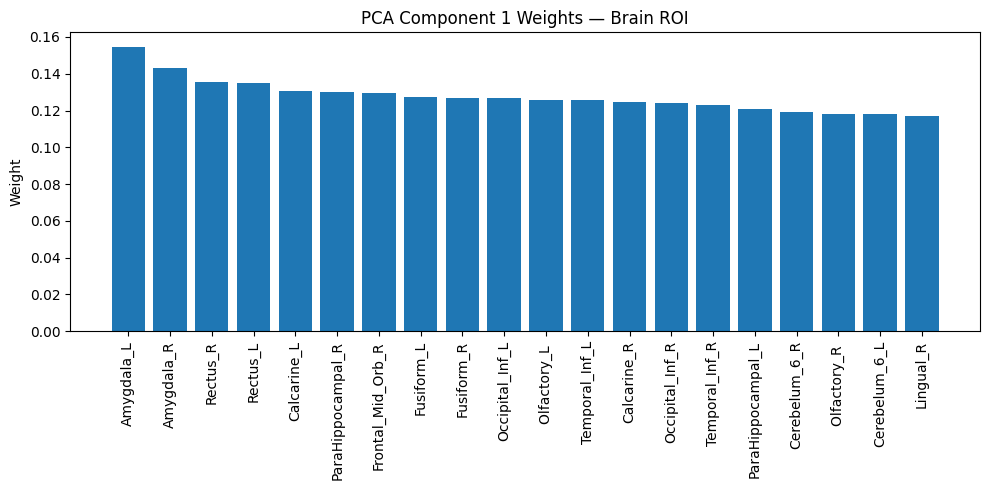

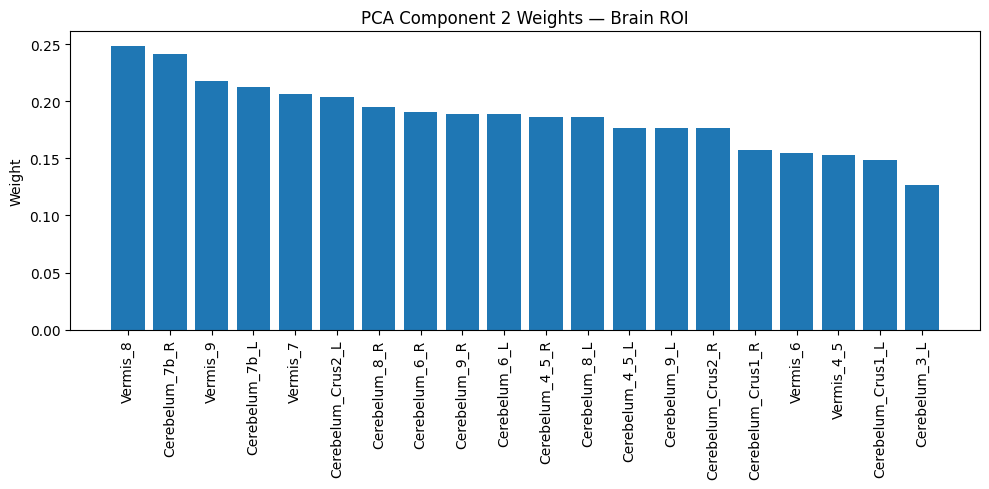

In [ ]:
# PCA components for brain data
W_brain_pca = pca_brain.components_

def plot_pca_component(w, feature_names, title, top_k=20):
    w = np.asarray(w).ravel()
    idx = np.argsort(np.abs(w))[::-1][:min(top_k, len(w))]
    w_top = w[idx]
    names_top = [feature_names[i] for i in idx]

    plt.figure(figsize=(10,5))
    plt.bar(range(len(w_top)), w_top)
    plt.xticks(range(len(w_top)), names_top, rotation=90)
    plt.ylabel("Weight")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot first two PCA components for brain data
plot_pca_component(W_brain_pca[0], brain_names, "PCA Component 1 Weights — Brain ROI")
plot_pca_component(W_brain_pca[1], brain_names, "PCA Component 2 Weights — Brain ROI")

#### Plotting PCA latent components (brain data)

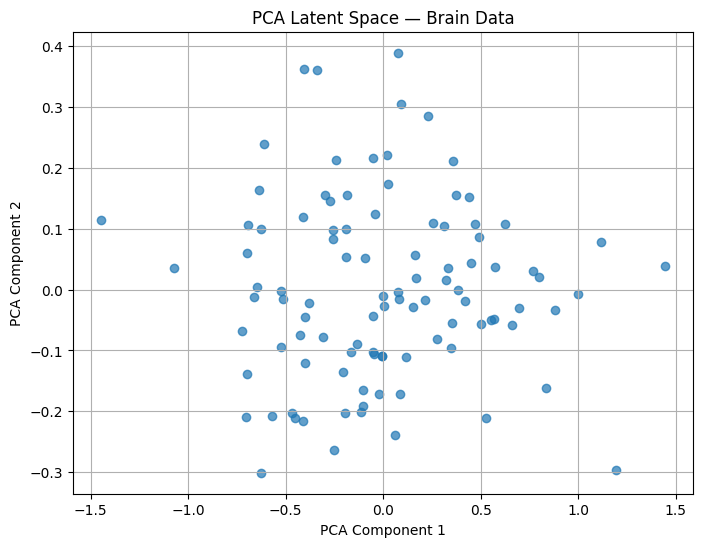

In [ ]:
# Z_brain_pca was obtained from:
# Z_brain_pca = pca_brain.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    Z_brain_pca[:, 0],
    Z_brain_pca[:, 1],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Latent Space — Brain Data")
plt.grid(True)

plt.show()

#### Plotting PCA components (clinical data)

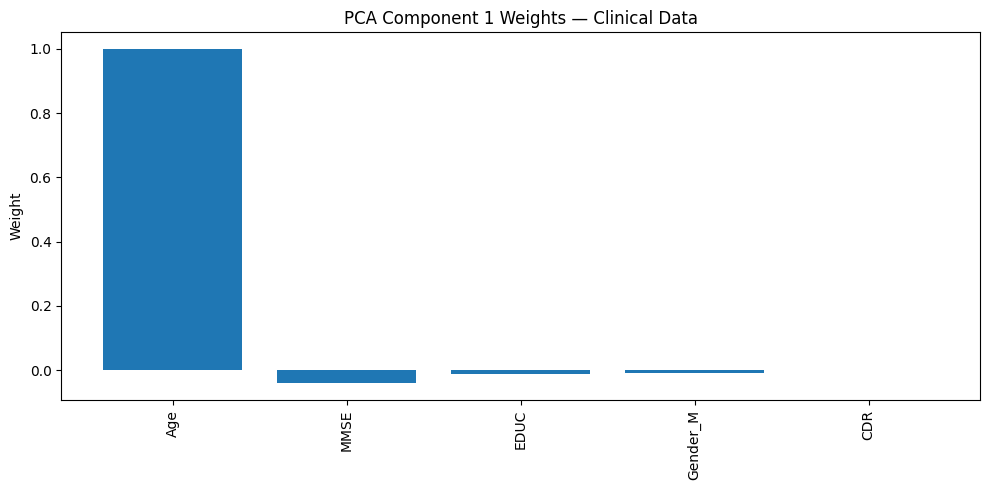

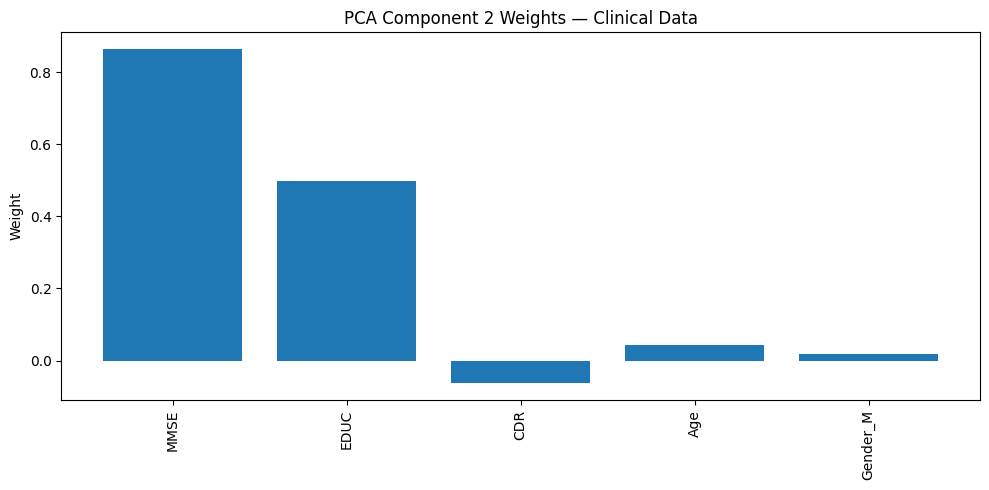

In [ ]:
# PCA component weights for clinical data
W_clinical_pca = pca_clinical.components_

def plot_pca_component(w, feature_names, title, top_k=20):
    w = np.asarray(w).ravel()
    idx = np.argsort(np.abs(w))[::-1][:min(top_k, len(w))]
    w_top = w[idx]
    names_top = [feature_names[i] for i in idx]

    plt.figure(figsize=(10,5))
    plt.bar(range(len(w_top)), w_top)
    plt.xticks(range(len(w_top)), names_top, rotation=90)
    plt.ylabel("Weight")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot first two PCA components
plot_pca_component(W_clinical_pca[0], clinical_names, "PCA Component 1 Weights — Clinical Data")
plot_pca_component(W_clinical_pca[1], clinical_names, "PCA Component 2 Weights — Clinical Data")

#### Plotting PCA latent components (clinical data)

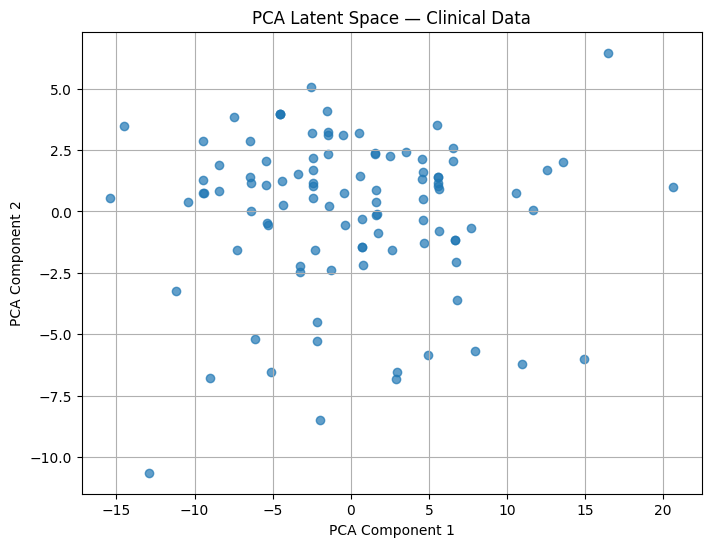

In [ ]:
# PCA latent space for clinical data
plt.figure(figsize=(8,6))

plt.scatter(
    Z_clinical_pca[:,0],
    Z_clinical_pca[:,1],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Latent Space — Clinical Data")
plt.grid(True)

plt.show()